In [ ]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd

from pathlib import Path

from qiskit import QuantumCircuit, transpile

from qiskit.circuit.library import zz_feature_map, real_amplitudes

from qiskit_machine_learning.algorithms import VQC

from qiskit_algorithms.optimizers import COBYLA

from qiskit_aer import AerSimulator

from qiskit_aer.noise import NoiseModel, depolarizing_error

from qiskit_ibm_runtime import SamplerV2 as Sampler

from sklearn.model_selection import train_test_split

from scipy.optimize import minimize

from qiskit_aer import StatevectorSimulator



In [24]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Dataset
n          = 2000    # Number of generated points
TEST_SIZE  = 0.2    # Fraction used for test set
SEED       = 1      # Random seed (data split & optimizer init)
N_DIM      = 3    # Features dimension

# Optimization
MAXITER    = 1000     # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER) 

# Noise 
USE_NOISE = False 
NOISE_RATE = 0.02
# ──────────────────────────────────────────────────────────────────────────────
REUPLOAD_SHOTS = 1024
RC_REUPLOAD = 8
MAXITER_REUPLOAD = 1000

In [25]:
if USE_NOISE:
    nm = NoiseModel()
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ['u', 'h', 'ry', 'rz'])
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ['cx'])
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    sampler = Sampler(backend)
else:
    sampler = Sampler(AerSimulator())

In [26]:
def generate_nsphere_data(n_samples, n_dim, radius=None, seed=None):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1, 1, (n_samples, n_dim))
    if radius is None:
        radius = np.sqrt(n_dim / 3)
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)
    return X, y, radius

In [27]:
X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM, seed=SEED)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)
print(X_train.shape, y_train.shape)

(1600, 3) (1600,)


In [28]:
def create_reupload_circuit(x, theta, omega, num_layers, n_dim, measure=False):
    """
    Creates a re-uploading circuit for 1 qubit.
    n_dim features are packed into U gates (3 features per gate).
    """
    qc = QuantumCircuit(1)
    n_gates_per_layer = int(np.ceil(n_dim / 3))
    for r in range(num_layers):
        qc.h(0)
        for g in range(n_gates_per_layer):
            params_u = []
            for i in range(3):
                idx = g * 3 + i
                # theta and omega have shape (num_layers, n_gates_per_layer * 3)
                val = theta[r, idx]
                if idx < n_dim:
                    val += omega[r, idx] * x[idx]
                params_u.append(val)
            qc.u(params_u[0], params_u[1], params_u[2], 0)
    if measure:
        qc.measure_all()
    return qc

def get_reupload_probs_batch(circuits, shots=REUPLOAD_SHOTS):
    """
    - Si USE_NOISE = True : exécute les circuits mesurés sur AerSimulator bruité.
    - Sinon : utilise StatevectorSimulator pour obtenir les probabilités exactes.
    """
    probs = []

    if USE_NOISE:
        measured_circuits = []
        for qc in circuits:
            qc_m = qc.copy()
            if qc_m.num_clbits == 0:
                qc_m.measure_all()
            measured_circuits.append(qc_m)

        transpiled_circuits = transpile(measured_circuits, backend)
        result = backend.run(transpiled_circuits, shots=shots).result()

        for qc_t in transpiled_circuits:
            counts = result.get_counts(qc_t)
            p0 = counts.get('0', 0) / shots
            p1 = counts.get('1', 0) / shots
            probs.append((p0, p1))
    else:
        sim = StatevectorSimulator()
        for qc in circuits:
            sv = sim.run(qc).result().get_statevector()
            p0 = float(np.abs(sv[0])**2)
            p1 = float(np.abs(sv[1])**2)
            probs.append((p0, p1))

    return probs


In [29]:
def unpack_reupload_params(params, num_layers, n_dim):
    n_gates_per_layer = int(np.ceil(n_dim / 3))
    n_params_per_layer = n_gates_per_layer * 3
    
    theta = params[:n_params_per_layer * num_layers].reshape(num_layers, n_params_per_layer)
    omega = params[n_params_per_layer * num_layers : 2 * n_params_per_layer * num_layers].reshape(num_layers, n_params_per_layer)
    alphas = params[2 * n_params_per_layer * num_layers:]
    return theta, omega, alphas

def reupload_cost_weighted(params, X, y, num_layers, n_dim):
    theta, omega, alphas = unpack_reupload_params(params, num_layers, n_dim)

    circuits = [create_reupload_circuit(x, theta, omega, num_layers, n_dim) for x in X]
    probs = get_reupload_probs_batch(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        weight = alphas[y_target] ** 2
        total_cost += weight * ((p0 - y_expected[0])**2 + (p1 - y_expected[1])**2)

    return 0.5 * total_cost / len(X)

def optimize_reupload_parameters(X, y, num_layers, n_dim, maxiter=MAXITER_REUPLOAD):
    n_gates_per_layer = int(np.ceil(n_dim / 3))
    n_params_per_layer = n_gates_per_layer * 3
    
    rng = np.random.default_rng(SEED)
    init = rng.uniform(-np.pi, np.pi, size=2 * n_params_per_layer * num_layers + 2)

    def objective(params):
        return reupload_cost_weighted(params, X, y, num_layers, n_dim)

    res = minimize(
        objective,
        init,
        method="COBYLA",
        options={"maxiter": maxiter}
    )

    theta_opt, omega_opt, alphas_opt = unpack_reupload_params(res.x, num_layers, n_dim)
    return res, theta_opt, omega_opt, alphas_opt

def predict_reupload_batch(X, theta, omega, num_layers, n_dim):
    circuits = [create_reupload_circuit(x, theta, omega, num_layers, n_dim) for x in X]
    probs = get_reupload_probs_batch(circuits)
    return np.array([0 if p0 >= p1 else 1 for p0, p1 in probs])

def evaluate_reupload(X, y, theta, omega, num_layers, n_dim):
    y_pred = predict_reupload_batch(X, theta, omega, num_layers, n_dim)
    accuracy = np.mean(y_pred == y)
    return {"accuracy": accuracy, "y_pred": y_pred}


In [ ]:
# Study: Accuracy vs Number of Re-uploading for dimensions 2 to 6



dimensions = [2, 3, 4, 5, 6]

layers_list = [1, 2, 4, 6, 8, 10, 14, 20]



# Temporary settings for the study to keep execution time reasonable

n_samples_study = 1000 

maxiter_study = 200 

original_use_noise = USE_NOISE

USE_NOISE = False  # Disable noise for this study to speed up calculations



records = []



for d in dimensions:

    print(f"\n========== Studying Dimension {d} ==========")

    X_d, y_d, R_d = generate_nsphere_data(n_samples=n_samples_study, n_dim=d, seed=SEED)

    X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(

        X_d, y_d, test_size=TEST_SIZE, random_state=SEED, stratify=y_d

    )

    

    for L in layers_list:

        print(f"--- Dimension {d}, Layers {L} ---")

        res, t_opt, o_opt, a_opt = optimize_reupload_parameters(

            X_train_d, y_train_d, num_layers=L, n_dim=d, maxiter=maxiter_study

        )

        metrics = evaluate_reupload(X_test_d, y_test_d, t_opt, o_opt, num_layers=L, n_dim=d)

        records.append({

            "dimension": d,

            "layers": L,

            "accuracy": metrics['accuracy']

        })

        print(f"Accuracy: {metrics['accuracy']:.4f}")



# Restore original noise setting

USE_NOISE = original_use_noise



# Save to Excel

output_path = Path("RESULTS/reupload_study.xlsx")

output_path.parent.mkdir(parents=True, exist_ok=True)

df_raw = pd.DataFrame(records)

summary = df_raw.groupby(["dimension", "layers"]).agg(

    mean_accuracy=("accuracy", "mean"),

    std_accuracy=("accuracy", "std"),

    n_runs=("accuracy", "size")

).reset_index()

with pd.ExcelWriter(output_path) as writer:

    df_raw.to_excel(writer, sheet_name="raw", index=False)

    summary.to_excel(writer, sheet_name="summary", index=False)

print(f"Results saved to {output_path}")




========== Studying Dimension 2 ==========
--- Dimension 2, Layers 1 ---
Accuracy: 0.7450
--- Dimension 2, Layers 2 ---
Accuracy: 0.4200
--- Dimension 2, Layers 4 ---
Accuracy: 0.5300
--- Dimension 2, Layers 6 ---
Accuracy: 0.5300
--- Dimension 2, Layers 8 ---
Accuracy: 0.5800
--- Dimension 2, Layers 10 ---
Accuracy: 0.7000
--- Dimension 2, Layers 14 ---
Accuracy: 0.5400
--- Dimension 2, Layers 20 ---
Accuracy: 0.7050

========== Studying Dimension 3 ==========
--- Dimension 3, Layers 1 ---
Accuracy: 0.6550
--- Dimension 3, Layers 2 ---
Accuracy: 0.4750
--- Dimension 3, Layers 4 ---
Accuracy: 0.5300
--- Dimension 3, Layers 6 ---
Accuracy: 0.6700
--- Dimension 3, Layers 8 ---
Accuracy: 0.5950
--- Dimension 3, Layers 10 ---
Accuracy: 0.6450
--- Dimension 3, Layers 14 ---


# Exemple de circuit pour une dimension 4

Ce qui se passe pour `n_dim = 4` : chaque couche comporte 2 portes `U` (car `ceil(4/3) = 2`). La première `U` encode `x0, x1, x2`; la seconde encode `x3` et possède deux paramètres libres sans données (indices 4 et 5). On illustre ci-dessous avec 2 couches et des paramètres aléatoires.

n_gates_per_layer=2, params_per_layer=6


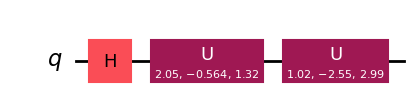

In [ ]:
# Circuit d'illustration pour n_dim=4 avec 2 couches

d_example = 4

num_layers_example = 1

x_example = np.array([0.2, -0.1, 0.4, 0.7])



n_gates_per_layer = int(np.ceil(d_example / 3))

n_params_per_layer = n_gates_per_layer * 3

rng = np.random.default_rng(42)

theta_example = rng.uniform(-np.pi, np.pi, size=(num_layers_example, n_params_per_layer))

omega_example = rng.uniform(-np.pi, np.pi, size=(num_layers_example, n_params_per_layer))



qc_example = create_reupload_circuit(x_example, theta_example, omega_example, num_layers_example, d_example)

print(f"n_gates_per_layer={n_gates_per_layer}, params_per_layer={n_params_per_layer}")

qc_example.draw(output="mpl")